In [ ]:
from RiskMetrics.conformal_prediction import generate_returns, backtest_model, HistoricalVaR, ParametricVaR, EWMAVaR, ConformalPIDPredictor, AdaptiveConformalInference
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from features_definition import FEATURES

In [ ]:
df = FEATURES

In [4]:
from scipy import stats

# -------------------------
# Simulate a return series
# -------------------------
np.random.seed(42)
n = 800

# GARCH-like volatility process for realism
returns = np.zeros(n)
vol = np.zeros(n)
vol[0] = 0.02
for t in range(1, n):
    vol[t] = 0.9 * vol[t-1] + 0.1 * np.abs(np.random.randn()) * 0.02
    returns[t] = vol[t] * stats.t.rvs(df=5)   # fat-tailed shocks

# -------------------------
# Simulate exogenous features
# -------------------------

# 1) Linear trend
trend = np.linspace(0, 1, n)

# 2) Seasonal factor (e.g., quarterly)
seasonal = 0.5 * np.sin(2 * np.pi * np.arange(n) / 50)

# 3) External AR(1) macro variable
macro = np.zeros(n)
for t in range(1, n):
    macro[t] = 0.8 * macro[t-1] + 0.05 * np.random.randn()

# Combine into X matrix (n, 3)
X = np.column_stack([trend, seasonal, macro])

df = pd.DataFrame({
    "returns": returns,
    "trend": trend,
    "seasonal": seasonal,
    "macro": macro
})

print(df.head())


    returns     trend  seasonal     macro
0  0.000000  0.000000  0.000000  0.000000
1 -0.002297  0.001252  0.062667 -0.075724
2  0.004432  0.002503  0.124345 -0.044499
3  0.013122  0.003755  0.184062  0.052147
4 -0.037896  0.005006  0.240877  0.042638


In [5]:
predictor_name='ar'
predictor_params={'lags': 3}
train_size = 250
alpha = 0.05
all_results = {}
all_details = {}

models = {
    'Historical VaR':HistoricalVaR(window_size=train_size),
    'Parametric VaR':ParametricVaR(window_size=train_size),
    'EWMA VaR':EWMAVaR(decay_factor=0.94, window_size=train_size),
    'Conformal P':ConformalPIDPredictor(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.1, use_integrator=False, use_scorecaster=False),
    'Conformal PI':ConformalPIDPredictor(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.1, use_integrator=True, use_scorecaster=False),
    'Conformal PID':ConformalPIDPredictor(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.1, use_integrator=True, use_scorecaster=True),
    'Conformal ACI':AdaptiveConformalInference(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.005, target_alpha=alpha),
}

print("\n" + "=" * 70)
print("RUN BACKTEST COMPARISON")
print(f"Target Coverage: {(1 - alpha) * 100}%")
print("=" * 70)

# Run Models
for model_name, model in models.items():
    print(f"\n Running {model_name}")
    all_results[model_name], all_details[model_name] = backtest_model(model=model, data=returns, X=X, train_size=train_size, alpha=alpha, model_name=model_name)
    print(f"Coverage: {all_results[model_name].coverage:.3f}")

print("\n" + "=" * 70)
print("BACKTEST COMPLETE")
print("=" * 70)


RUN BACKTEST COMPARISON
Target Coverage: 95.0%

 Running Historical VaR
Coverage: 0.893

 Running Parametric VaR
Coverage: 0.905

 Running EWMA VaR
Coverage: 0.896

 Running Conformal P
Coverage: 0.949

 Running Conformal PI
Coverage: 0.949

 Running Conformal PID
Coverage: 0.862

 Running Conformal ACI
Coverage: 0.949

BACKTEST COMPLETE


In [6]:
# CREATE SUMMARY TABLE
summary_data = []
for name, result in all_results.items():
    summary_data.append({
        'Method': name,
        'Coverage': f"{result.coverage:.1%}",
        'Target': f'{result.target_coverage:.1%}',
        'Coverage Gap': f'{(result.coverage - result.target_coverage) * 100:+.1f}%',
        'Violations': result.violations,
        'Average Width': f'{result.avg_interval_width:.4f}',
        'Kupiec p-value': f'{result.kupiec_pvalue:.3f}',
        'Christoff. p-value': f'{result.conditional_coverage_pvalue:.3f}'
    })

summary_df = pd.DataFrame(summary_data)
print('\n' + summary_df.to_string(index=False))


        Method Coverage Target Coverage Gap  Violations Average Width Kupiec p-value Christoff. p-value
Historical VaR    89.3%  95.0%        -5.7%          59        0.0647          0.000              0.000
Parametric VaR    90.5%  95.0%        -4.5%          52        0.0673          0.000              0.000
      EWMA VaR    89.6%  95.0%        -5.4%          57        0.0656          0.000              0.000
   Conformal P    94.9%  95.0%        -0.1%          28        0.1484          0.922              1.000
  Conformal PI    94.9%  95.0%        -0.1%          28        0.1488          0.922              1.000
 Conformal PID    86.2%  95.0%        -8.8%          76        0.0606          0.000              0.000
 Conformal ACI    94.9%  95.0%        -0.1%          28        0.0823          0.922              1.000


In [15]:
# COVERAGE COMPARISON BAR CHART

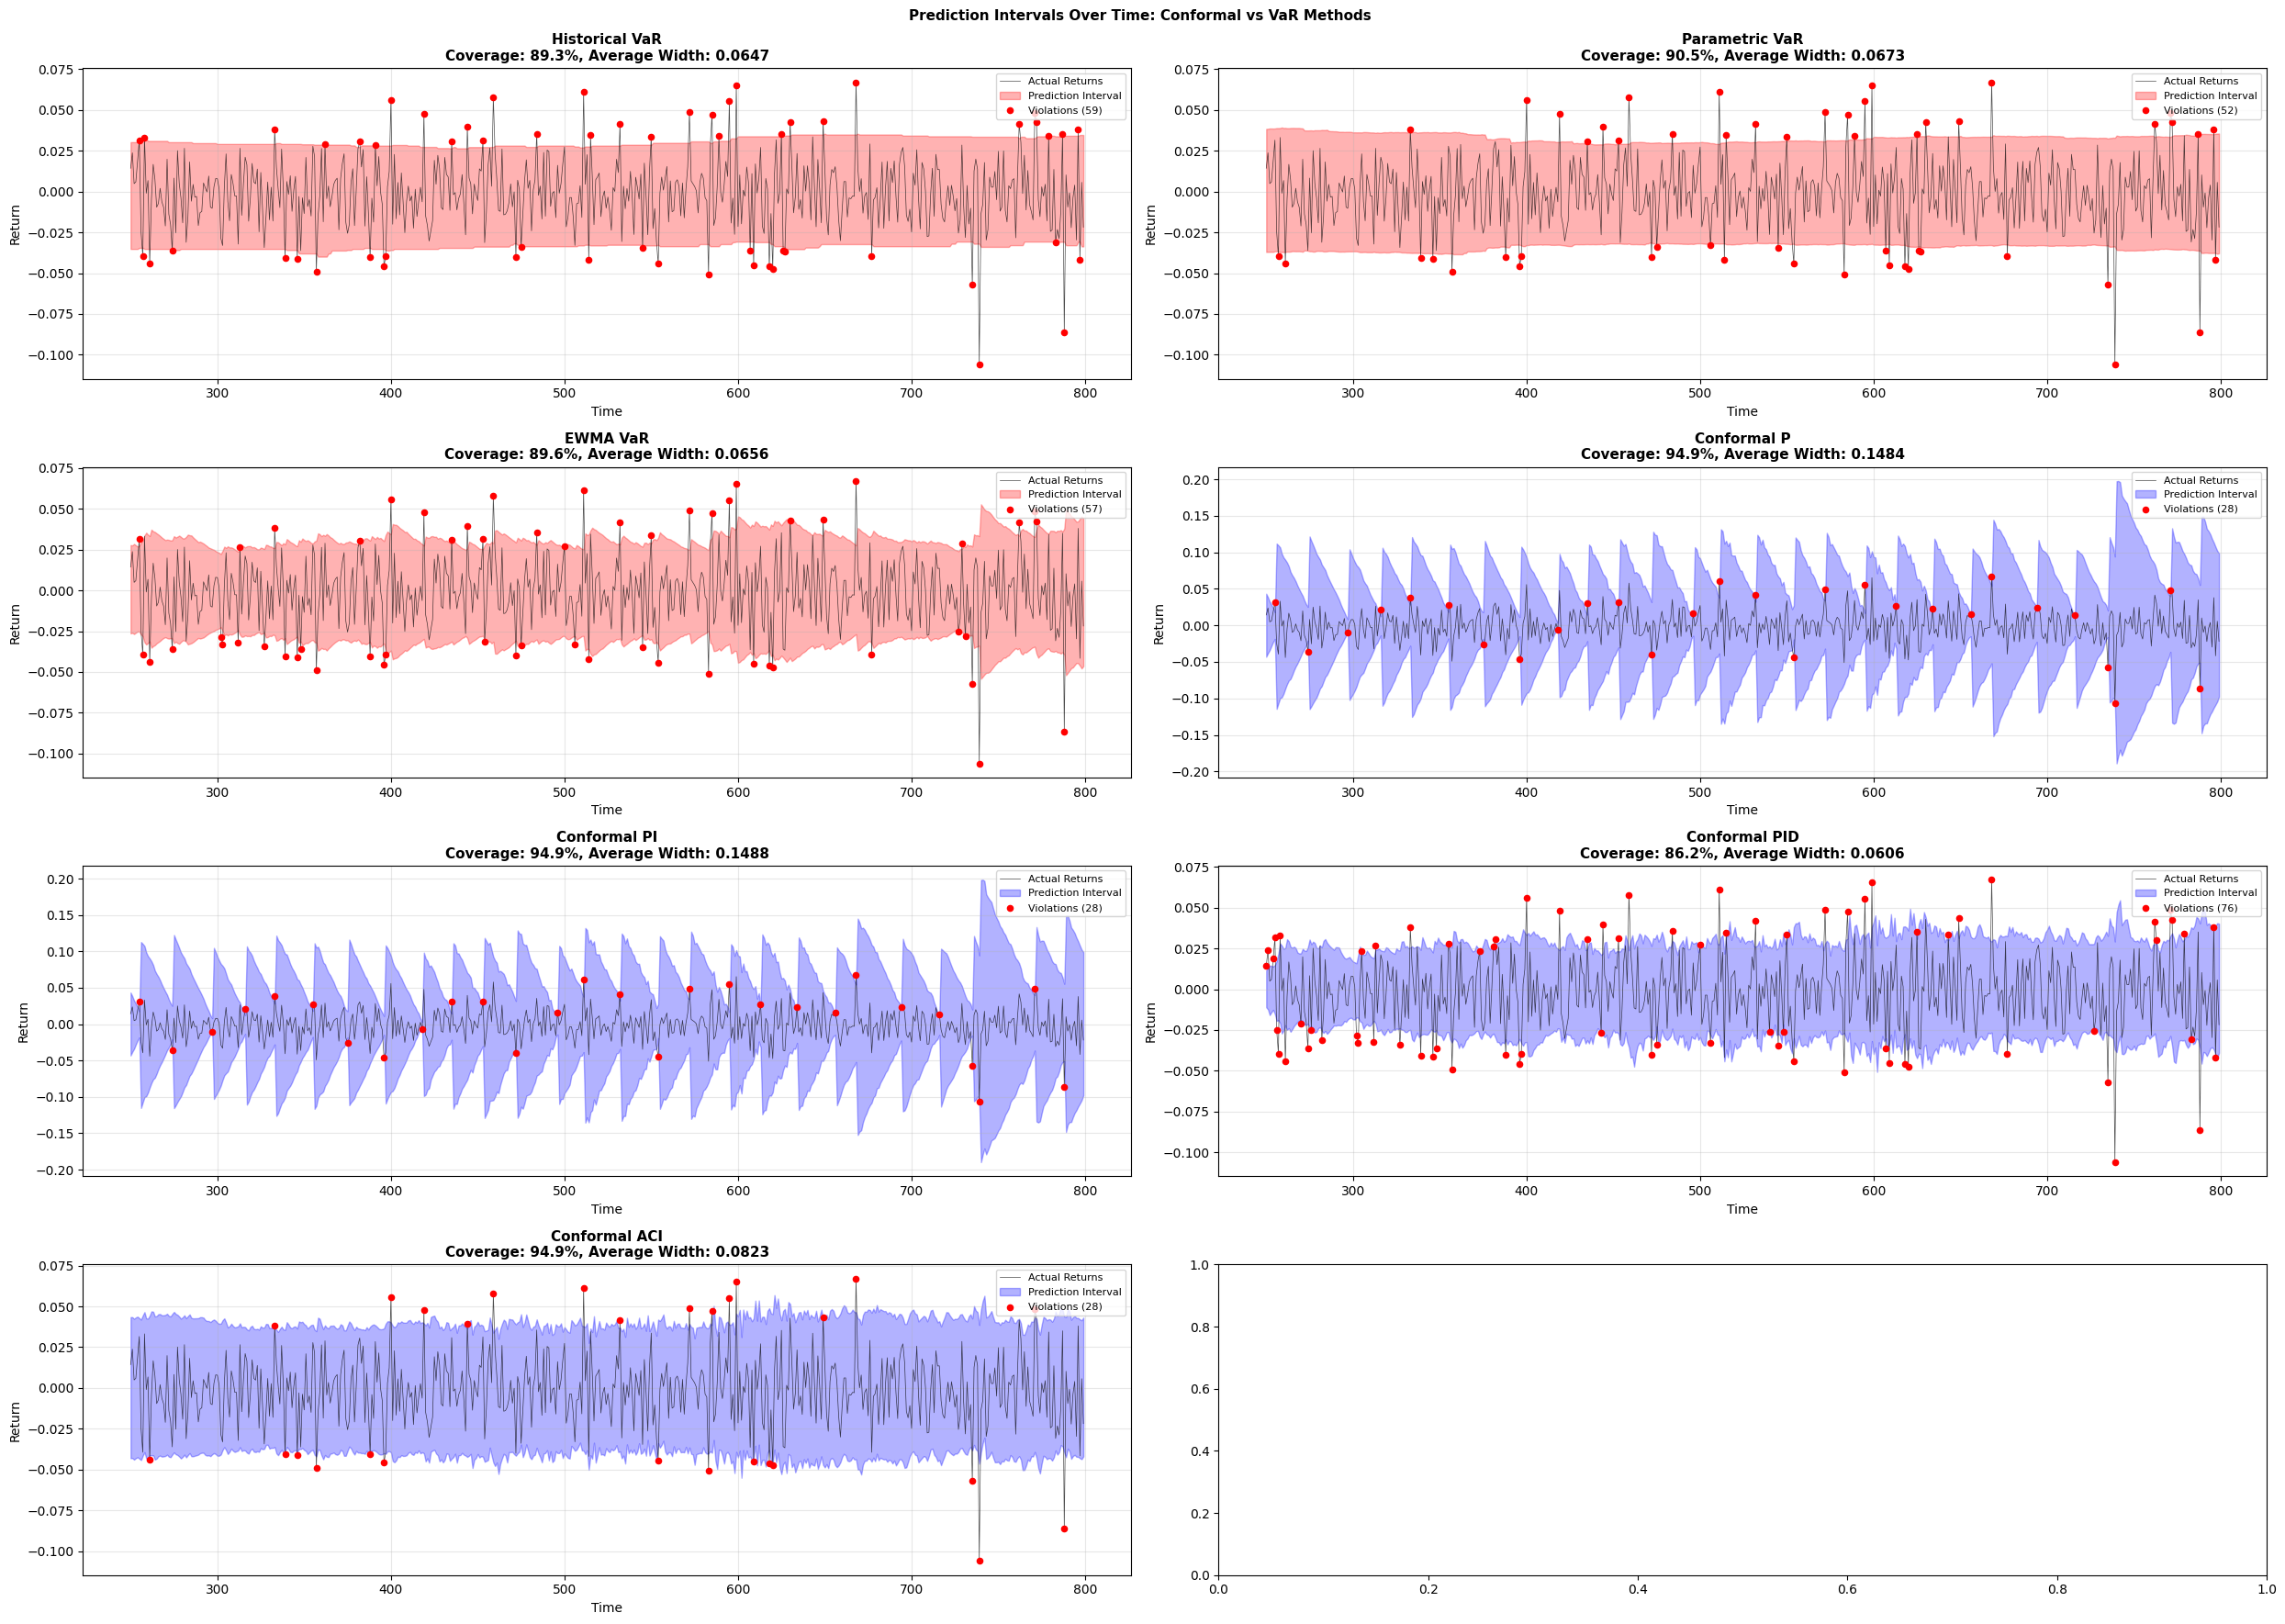

In [7]:
# TIME SERIES OF PREDICTION INTERVALS

fig, axes = plt.subplots(4,2,figsize=(25,18))
methods_to_plot = list(models.keys())

for idx, method in enumerate(methods_to_plot):
    ax = axes[idx // 2, idx % 2]
    df = all_details[method]

    # Plot actual returns
    ax.plot(df['time'], df['actual'], 'k-', linewidth=0.5, alpha=0.7, label='Actual Returns')

    # Plot Prediction interval
    ax.fill_between(df['time'], df['lower'], df['upper'], alpha=0.3, color='blue' if 'Conformal' in method or method == 'ACI' else 'red', label = 'Prediction Interval')

    # mark breaches
    violations_df = df[df['violation']==True]
    ax.scatter(violations_df['time'], violations_df['actual'], color='red', s=20, zorder=5, label=f'Violations ({len(violations_df)})')

    ax.set_title(f'{method}\nCoverage: {all_results[method].coverage:.1%}, '
                 f'Average Width: {all_results[method].avg_interval_width:.4f}',
                 fontsize=11, fontweight='bold')

    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Return', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Prediction Intervals Over Time: Conformal vs VaR Methods \n', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

